# E-Commerce Sales Analytics

## End-to-End Data Analytics Project

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- SQLite
- Google Colab

### Project Objectives
- Perform data cleaning
- Conduct exploratory data analysis
- Analyze business performance
- Write SQL queries using SQLite
- Generate actionable business insights

**Author:** Diya

# Table of Contents

1. Sprint 1 – Data Loading & Understanding
2. Sprint 2 – Data Cleaning
3. Sprint 3 – Exploratory Data Analysis
4. Sprint 4 – Advanced Business Analysis
5. Sprint 5 – SQL Analysis using SQLite
6. Project Summary

# Final Conclusion

This project demonstrates the complete workflow of a Data Analytics project.

The dataset was cleaned and analyzed using Python and Pandas. Business insights were generated through visualizations, and SQL queries were used to perform structured business analysis within SQLite.

Key findings include:
- Identification of top-performing categories and sub-categories
- Detection of loss-making products and states
- Analysis of sales, profit, and discounts
- Practical application of SQL for business decision-making

This project strengthened skills in Python, SQL, data visualization, and business analytics.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel('/content/SampleSuperstore.csv.xlsx')

# Display first 5 rows
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [2]:
# Number of rows and columns
df.shape

(9994, 13)

In [3]:
# List of column names
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [4]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [5]:
# Statistical summary
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Missing values in each column
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(17)

In [8]:
# Create a copy
df_clean = df.copy()

In [9]:
df_clean.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [10]:
missing = (df_clean.isnull().sum() / len(df_clean)) * 100

missing.sort_values(ascending=False)

,0
Ship Mode,0.0
Segment,0.0
Country,0.0
City,0.0
State,0.0
Postal Code,0.0
Region,0.0
Category,0.0
Sub-Category,0.0
Sales,0.0


In [11]:
print("Duplicates:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicates after cleaning:", df_clean.duplicated().sum())

Duplicates: 17
Duplicates after cleaning: 0


In [12]:
df_clean.dtypes

,0
Ship Mode,object
Segment,object
Country,object
City,object
State,object
Postal Code,int64
Region,object
Category,object
Sub-Category,object
Sales,float64


In [13]:
df_clean[['Sales', 'Quantity', 'Profit']].describe()

,Sales,Quantity,Profit
count,9977.000000,9977.000000,9977.00000
mean,230.148902,3.790719,28.69013
std,623.721409,2.226657,234.45784
min,0.444000,1.000000,-6599.97800
25%,17.300000,2.000000,1.72620
50%,54.816000,3.000000,8.67100
75%,209.970000,5.000000,29.37200
max,22638.480000,14.000000,8399.97600


In [14]:
df_clean['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [15]:
df_clean['Region'].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [16]:
df_clean['Segment'].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [17]:
df_clean['Category'] = df_clean['Category'].str.strip()
df_clean['Region'] = df_clean['Region'].str.strip()

In [18]:
df_clean['Category'] = df_clean['Category'].str.title()

In [19]:
df_clean.to_csv("cleaned_ecommerce_data.csv", index=False)

Which category generates the highest sales?

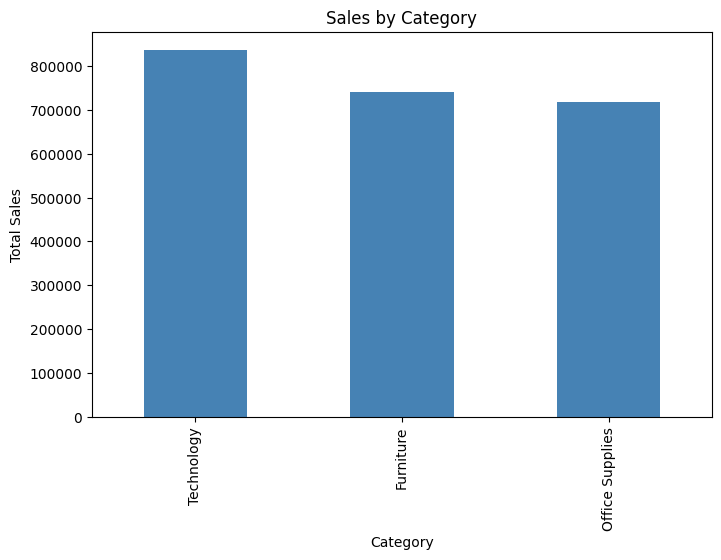

Category
Technology         836154.0330
Furniture          741306.3133
Office Supplies    718735.2440
Name: Sales, dtype: float64


In [20]:
import matplotlib.pyplot as plt

category_sales = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='steelblue')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

print(category_sales)

In [21]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Which category earns the most profit?

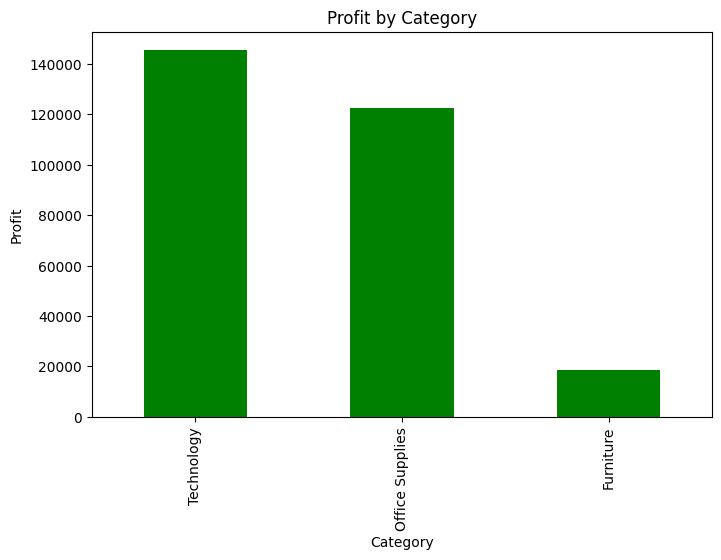

Category
Technology         145454.9481
Office Supplies    122364.6608
Furniture           18421.8137
Name: Profit, dtype: float64


In [22]:
category_profit = df_clean.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar', color='green')

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.show()

print(category_profit)

In [23]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Which sub-category generates the highest sales?

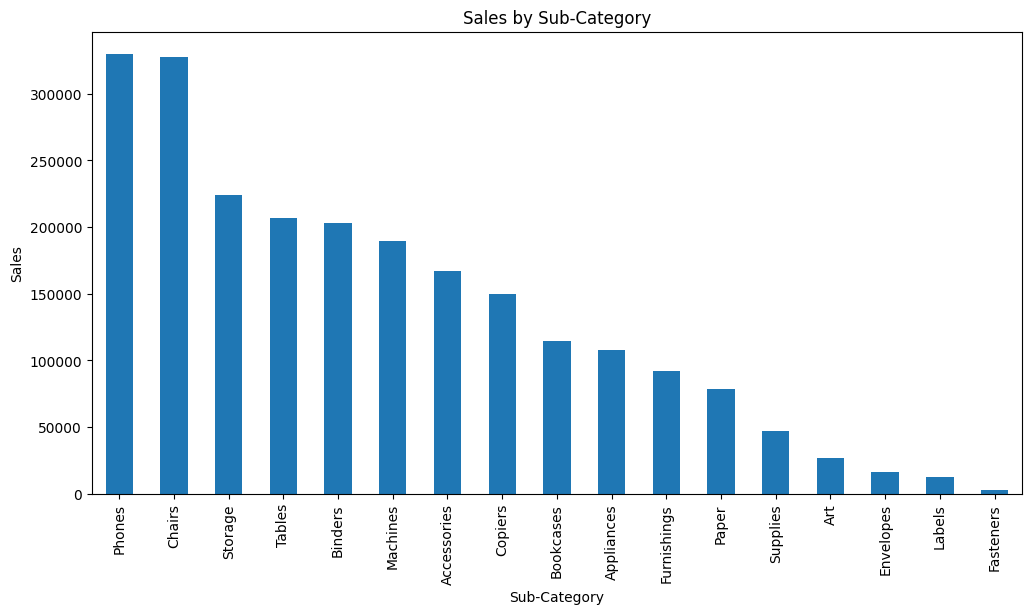

In [24]:
subcategory_sales = (
    df_clean.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
subcategory_sales.plot(kind='bar')

plt.title("Sales by Sub-Category")
plt.ylabel("Sales")

plt.show()

In [25]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Which region performs best?

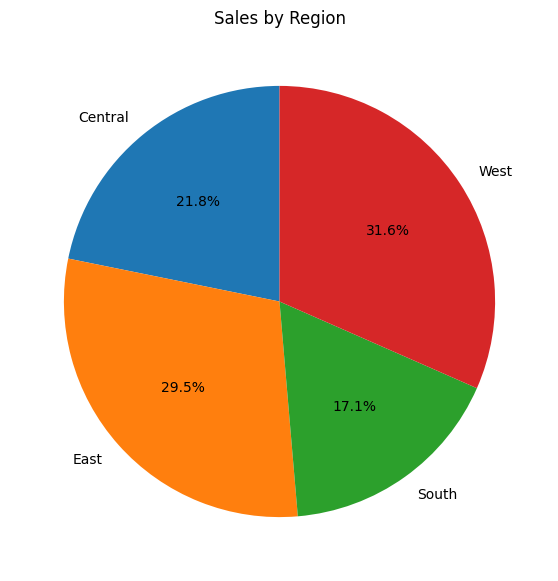

In [26]:
region_sales = df_clean.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Region")

plt.show()

In [27]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Which states have the highest sales?

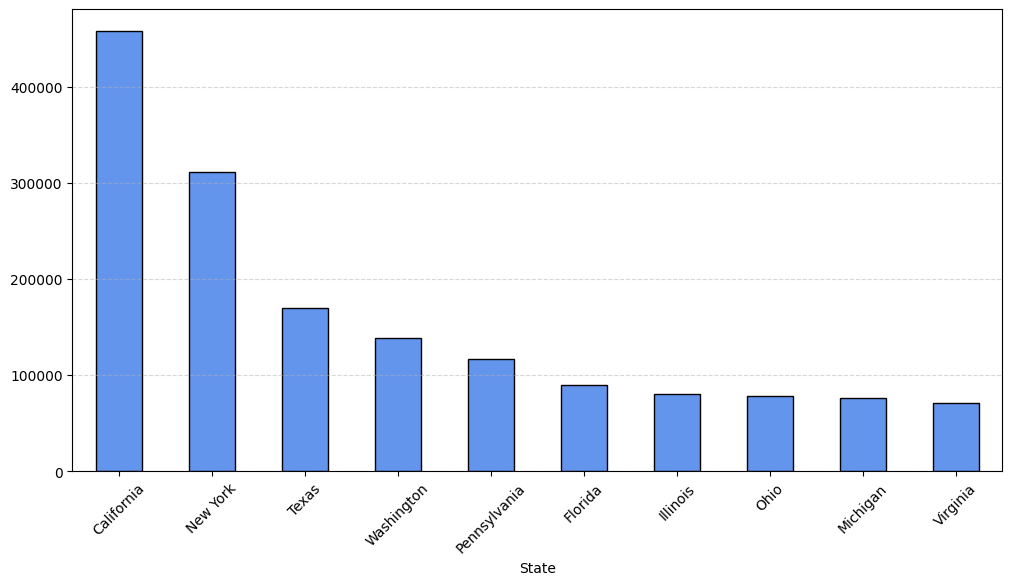

In [28]:
state_sales = (
    df_clean.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sales.plot(
    kind='bar',
    figsize=(12,6),
    color='cornflowerblue',
    edgecolor='black'
)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [29]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Does discount reduce profit?

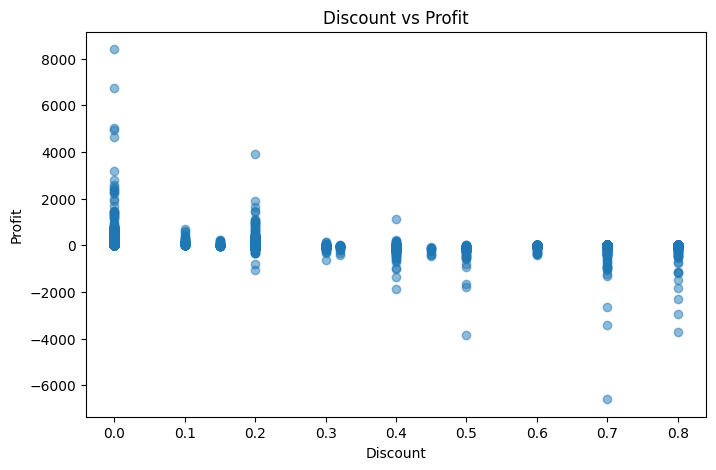

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_clean['Discount'],
    df_clean['Profit'],
    alpha=0.5
)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()



In [31]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

Correlation Matrix

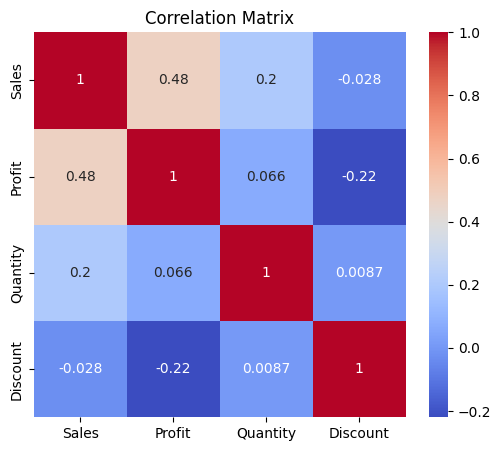

In [32]:
import seaborn as sns

corr = df_clean[['Sales','Profit','Quantity','Discount']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [33]:
plt.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

we perform deeper business analysis to identify profitable products, loss-making areas, discount impact, and revenue contribution. The insights generated here help businesses make data-driven decisions.

## Question 1: Which Sub-Categories Generate the Highest Profit?

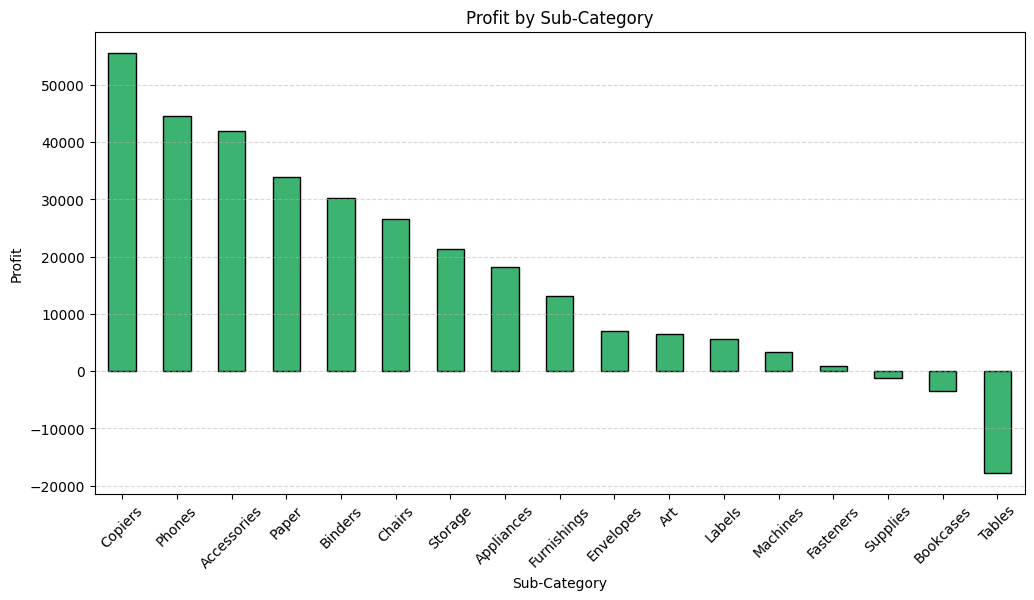

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          33944.2395
Binders        30228.0003
Chairs         26567.1278
Storage        21278.8264
Appliances     18138.0054
Furnishings    13052.7230
Envelopes       6964.1767
Art             6524.6118
Labels          5526.3820
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


In [34]:
import matplotlib.pyplot as plt

subcategory_profit = (
    df_clean.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

subcategory_profit.plot(
    kind='bar',
    color='mediumseagreen',
    edgecolor='black'
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(subcategory_profit)

### Business Insights

- The highest-profit sub-category is Copiers.
- The company earns significant profit from this product line.
- These products should be prioritized for marketing and inventory.

### Recommendation

Increase promotions and maintain adequate stock for the most profitable sub-category.

## Question 2: Which Sub-Categories Are Loss-Making?

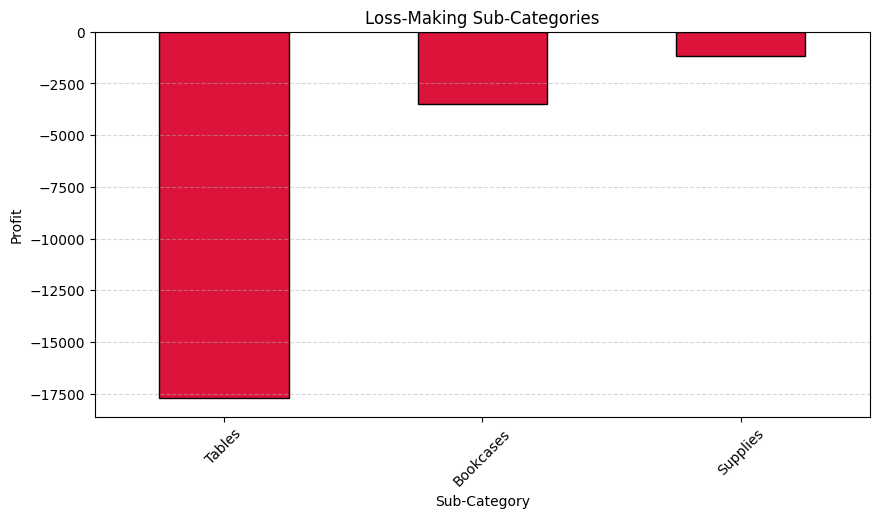

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


In [35]:
loss_subcategory = (
    df_clean.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
)

loss_subcategory = loss_subcategory[loss_subcategory < 0]

plt.figure(figsize=(10,5))

loss_subcategory.plot(
    kind='bar',
    color='crimson',
    edgecolor='black'
)

plt.title("Loss-Making Sub-Categories")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(loss_subcategory)

### Business Insights

- These sub-categories are generating an overall loss.
- Their pricing, discount strategy, or procurement costs should be reviewed.

### Recommendation

Investigate the root cause of losses and optimize pricing or supplier costs.

## Question 3: Which States Are Loss-Making?

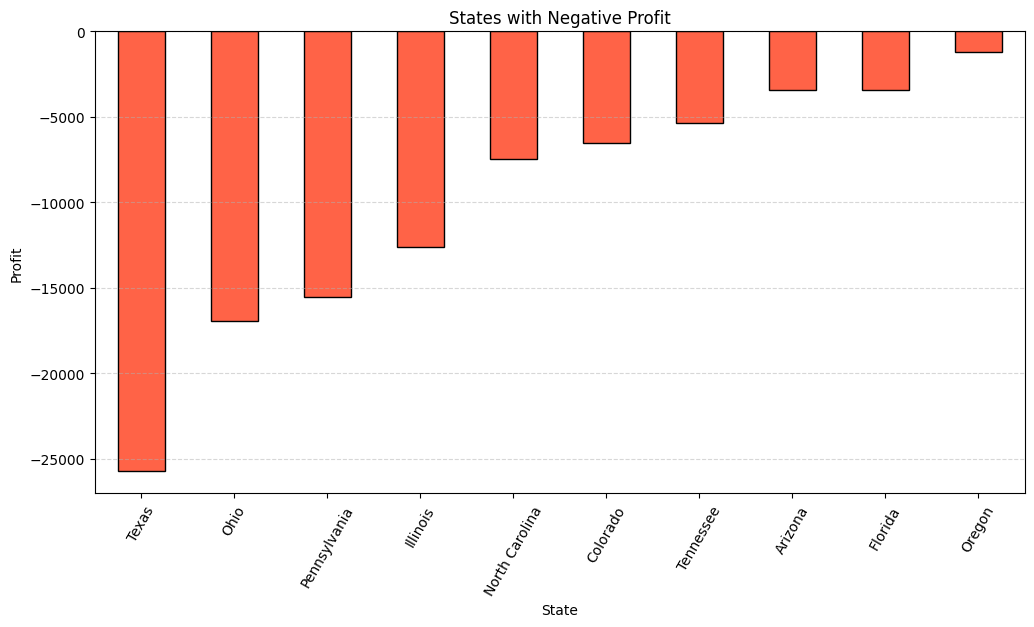

State
Texas            -25750.9833
Ohio             -16959.3178
Pennsylvania     -15565.4035
Illinois         -12601.6500
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1194.0993
Name: Profit, dtype: float64


In [36]:
loss_states = (
    df_clean.groupby('State')['Profit']
    .sum()
    .sort_values()
)

loss_states = loss_states[loss_states < 0]

plt.figure(figsize=(12,6))

loss_states.plot(
    kind='bar',
    color='tomato',
    edgecolor='black'
)

plt.title("States with Negative Profit")
plt.xlabel("State")
plt.ylabel("Profit")

plt.xticks(rotation=60)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(loss_states)

### Business Insights

- Certain states are generating negative profit.
- Regional strategies should be evaluated to understand why profitability is low.

### Recommendation

Review pricing, logistics costs, and promotional campaigns in these states.

## Question 4: What Percentage of Total Sales Does Each Category Contribute?

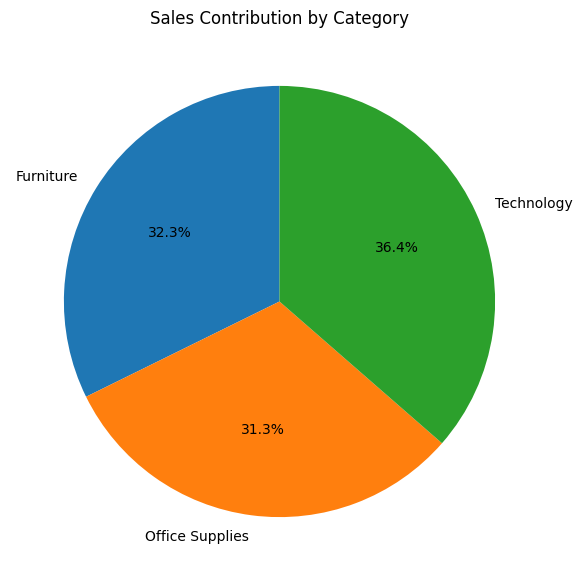

Category
Furniture          32.284110
Office Supplies    31.301133
Technology         36.414757
Name: Sales, dtype: float64


In [37]:
sales_percentage = (
    df_clean.groupby('Category')['Sales']
    .sum()
)

sales_percentage = (
    sales_percentage / sales_percentage.sum()
) * 100

plt.figure(figsize=(7,7))

plt.pie(
    sales_percentage,
    labels=sales_percentage.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales Contribution by Category")

plt.show()

print(sales_percentage)

### Business Insights

- This chart shows each category's contribution to total revenue.
- It helps identify the company's primary revenue sources.

### Recommendation

Focus on maintaining strong performance in high-contributing categories while improving weaker ones.

## Question 5: What Is the Average Profit for Each Category?

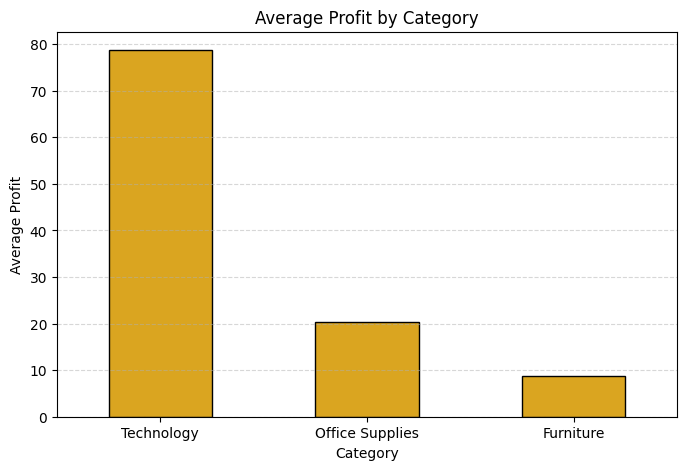

Category
Technology         78.752002
Office Supplies    20.353403
Furniture           8.697740
Name: Profit, dtype: float64


In [38]:
avg_profit = (
    df_clean.groupby('Category')['Profit']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_profit.plot(
    kind='bar',
    color='goldenrod',
    edgecolor='black'
)

plt.title("Average Profit by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

print(avg_profit)

### Business Insights

- Average profit provides a clearer view of profitability than total profit.
- Categories with high average profit may offer better long-term opportunities.

### Recommendation

Increase focus on categories that consistently deliver strong average profits.

# Sprint 5: SQL Analysis using SQLite

In this sprint, we will use SQLite in Google Colab to perform SQL queries on the cleaned e-commerce dataset. This helps us analyze business data using SQL without installing any software.

In [39]:
import sqlite3
import pandas as pd

In [40]:
# Create an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Create a cursor
cursor = conn.cursor()

In [41]:
df_sql = pd.read_csv("cleaned_ecommerce_data.csv")

df_sql.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [42]:
df_sql.to_sql(
    "ecommerce_sales",
    conn,
    if_exists="replace",
    index=False
)

print("Table created successfully!")

Table created successfully!


In [43]:
pd.read_sql(
    "SELECT * FROM ecommerce_sales LIMIT 5;",
    conn
)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Question 1: Display All Records

This query retrieves every record from the **ecommerce_sales** table. It is useful for verifying that the data has been loaded correctly into the SQLite database.

In [44]:
query = """
SELECT *
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)

result

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9972,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9973,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9974,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9975,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


## Question 2: Display Category, Sales and Profit

This query retrieves only the **Category**, **Sales**, and **Profit** columns, allowing us to focus on the most important business metrics.

In [45]:
query = """
SELECT
Category,
Sales,
Profit
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)

result

,Category,Sales,Profit
0,Furniture,261.9600,41.9136
1,Furniture,731.9400,219.5820
2,Office Supplies,14.6200,6.8714
3,Furniture,957.5775,-383.0310
4,Office Supplies,22.3680,2.5164
...,...,...,...
9972,Furniture,25.2480,4.1028
9973,Furniture,91.9600,15.6332
9974,Technology,258.5760,19.3932
9975,Office Supplies,29.6000,13.3200


## Question 3: Count Total Records

This query counts the total number of records available in the dataset.

In [46]:
query = """
SELECT
COUNT(*) AS Total_Records
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)

result

,Total_Records
0,9977


### Business Insight

Knowing the total number of records helps us understand the size of the dataset before performing further analysis.

## Question 4: Calculate Total Sales

This query calculates the overall sales generated by the company.

In [47]:
query = """
SELECT
ROUND(SUM(Sales),2) AS Total_Sales
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)

result

,Total_Sales
0,2296195.59


### Business Insight

Total sales represent the company's overall revenue generated from all transactions.

## Question 5: Calculate Total Profit

This query calculates the total profit earned across all sales.

In [48]:
query = """
SELECT
ROUND(SUM(Profit),2) AS Total_Profit
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)

result

,Total_Profit
0,286241.42


### Business Insight

Total profit indicates the overall financial performance of the business after accounting for profits and losses from all transactions.

## Question 6: Calculate Total Sales by Category

This query groups the data by **Category** and calculates the total sales for each category.

In [49]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM ecommerce_sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql(query, conn)

result

,Category,Total_Sales
0,Technology,836154.03
1,Furniture,741306.31
2,Office Supplies,718735.24


### Business Insight

This analysis identifies which product category contributes the highest sales. It helps businesses focus marketing efforts and inventory planning on their strongest-performing categories.

## Question 7: Calculate Total Profit by Category

This query calculates the total profit generated by each product category.

In [50]:
query = """
SELECT
    Category,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM ecommerce_sales
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql(query, conn)

result

,Category,Total_Profit
0,Technology,145454.95
1,Office Supplies,122364.66
2,Furniture,18421.81


### Business Insight

A category with high sales may not always generate the highest profit. This analysis helps identify the most profitable categories.

## Question 8: Top 10 States by Sales

This query identifies the top 10 states based on total sales.

In [51]:
query = """
SELECT
    State,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM ecommerce_sales
GROUP BY State
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,State,Total_Sales
0,California,457576.27
1,New York,310827.15
2,Texas,170124.54
3,Washington,138560.81
4,Pennsylvania,116496.36
5,Florida,89473.71
6,Illinois,80162.54
7,Ohio,77976.76
8,Michigan,75879.64
9,Virginia,70636.72


### Business Insight

The highest-selling states represent the company's strongest regional markets and can guide future sales and expansion strategies.

## Question 9: Top 10 Sub-Categories by Sales

This query identifies the ten best-selling sub-categories based on total sales.

In [52]:
query = """
SELECT
    [Sub-Category],
    ROUND(SUM(Sales),2) AS Total_Sales
FROM ecommerce_sales
GROUP BY [Sub-Category]
ORDER BY Total_Sales DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,Sub-Category,Total_Sales
0,Phones,330007.05
1,Chairs,327777.76
2,Storage,223843.61
3,Tables,206965.53
4,Binders,203409.17
5,Machines,189238.63
6,Accessories,167380.32
7,Copiers,149528.03
8,Bookcases,114880.00
9,Appliances,107532.16


### Business Insight

Top-performing sub-categories reveal which specific products drive the highest revenue and deserve greater attention in inventory and marketing.

## Question 10: Average Discount by Category

This query calculates the average discount offered for each product category.

In [53]:
query = """
SELECT
    Category,
    ROUND(AVG(Discount),2) AS Average_Discount
FROM ecommerce_sales
GROUP BY Category
ORDER BY Average_Discount DESC;
"""

result = pd.read_sql(query, conn)

result

,Category,Average_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


### Business Insight

Analyzing average discounts helps determine which categories rely more heavily on promotions and whether those discounts are justified by sales and profit.

## Question 11: Find Loss-Making States

This query identifies the states where the total profit is negative.

In [54]:
query = """
SELECT
    State,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM ecommerce_sales
GROUP BY State
HAVING SUM(Profit) < 0
ORDER BY Total_Profit;
"""

result = pd.read_sql(query, conn)
result

,State,Total_Profit
0,Texas,-25750.98
1,Ohio,-16959.32
2,Pennsylvania,-15565.40
3,Illinois,-12601.65
4,North Carolina,-7490.91
5,Colorado,-6527.86
6,Tennessee,-5341.69
7,Arizona,-3427.92
8,Florida,-3399.30
9,Oregon,-1194.10


### Business Insight

States with negative profit require further investigation. High discounts, operational costs, or poor product performance could be contributing factors.

## Question 12: Find Loss-Making Sub-Categories

This query identifies the sub-categories whose total profit is negative.

In [55]:
query = """
SELECT
    [Sub-Category],
    ROUND(SUM(Profit),2) AS Total_Profit
FROM ecommerce_sales
GROUP BY [Sub-Category]
HAVING SUM(Profit) < 0
ORDER BY Total_Profit;
"""

result = pd.read_sql(query, conn)
result

,Sub-Category,Total_Profit
0,Tables,-17725.48
1,Bookcases,-3472.56
2,Supplies,-1189.10


### Business Insight

Loss-making sub-categories should be reviewed to improve pricing, reduce discounts, or optimize inventory.

## Question 13: Find the Most Profitable Sub-Category

This query identifies the sub-category that generates the highest total profit.

In [56]:
query = """
SELECT
    [Sub-Category],
    ROUND(SUM(Profit),2) AS Total_Profit
FROM ecommerce_sales
GROUP BY [Sub-Category]
ORDER BY Total_Profit DESC
LIMIT 1;
"""

result = pd.read_sql(query, conn)
result

,Sub-Category,Total_Profit
0,Copiers,55617.82


### Business Insight

The highest-profit sub-category contributes significantly to business profitability and should be prioritized for growth and promotion.

## Question 14: Find the Highest Discount

This query returns the maximum discount provided in the dataset.

In [57]:
query = """
SELECT
    MAX(Discount) AS Highest_Discount
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)
result

,Highest_Discount
0,0.8


### Business Insight

Knowing the highest discount helps evaluate the company's promotional strategy and identify unusually large discounts.

## Question 15: Find the Lowest Profit

This query identifies the minimum profit recorded in the dataset.

In [58]:
query = """
SELECT
    MIN(Profit) AS Lowest_Profit
FROM ecommerce_sales;
"""

result = pd.read_sql(query, conn)
result

,Lowest_Profit
0,-6599.978


### Business Insight

The lowest profit value highlights the largest single loss in the dataset. Investigating these transactions can help reduce future losses.

# Sprint 5 Summary

## Key Business Findings

1. SQL was used to analyze the cleaned e-commerce dataset directly within Google Colab using SQLite.

2. Sales and profit were analyzed across different categories, states, and sub-categories.

3. Top-performing product categories and states were identified using SQL aggregation queries.

4. Loss-making states and sub-categories were detected using the HAVING clause, helping identify areas that require business improvement.

5. Aggregate functions such as COUNT(), SUM(), AVG(), MAX(), and MIN() were used to generate meaningful business insights.

## SQL Concepts Learned

- SELECT
- WHERE
- COUNT()
- SUM()
- AVG()
- MIN()
- MAX()
- ROUND()
- GROUP BY
- ORDER BY
- LIMIT
- HAVING

## Conclusion

SQLite enabled efficient SQL analysis within Google Colab without requiring additional software installation. This sprint strengthened practical SQL skills and demonstrated how SQL can be used alongside Python for business data analysis.